# INF8111 - Fouille de données 
## Été 2026 - TP1 - Préparation des données de séries temporelles-Consommation électrique
### Membres de l'équipe 
    - Yacoubi, Yacine - 2268955 - 1
    - Falouh, Ghadi - 2250742 - 2
    - Yacoubi, Ali - 2252586 - 3


## Instructions de remise 

Vous devez remettre dans la boîte de remise sur moodle ce fichier nommé TP1\_NomDuMembre1\_NomDuMembre2\_NomDuMembre3.ipynb

**N.B**: Assurez-vous que tous les résultats soient lisibles lorsque le notebook est ouvert.

Ce notebook doit être remis avant le **24 mai 2026 à 23h59***. À l'ouverture du Notebook, toutes les réponses doivent être visibles. Tout travail en retard sera pénalisé d’une valeur de 10\% par jour ouvrable de retard.

## Barème

    Partie 1: 20 points
    
    Partie 2: 30 points
    
    Partie 3: 50 points
    
    Pour un total de 100 points.

## Séries temporelles 

Les séries temporelles sont de plus en plus utilisées dans plusieurs domaines tels aue la finance, la météorologie, la santé et la gestion de l'énergie pour modéliser, analyser et prévoir des phénomènes évolutifs. Une série temporelle correspond à une suite d’observations ordonnées dans le temps, collectées à intervalles réguliers ou irréguliers (par exemple : prix journaliers d’une action, température horaire, consommation électrique, etc.). 
Ces données présentent une structure particulière caractérisée par la dépendance entre les observations successives. À partir de ces données temporelles, il devient possible d’identifier des tendances à long terme, des cycles saisonniers, ainsi que des anomalies ou événements inhabituels. Par exemple, en finance, elles servent à anticiper les fluctuations des marchés ; en météorologie, à prévoir les conditions climatiques ; en santé, à suivre l’évolution de paramètres physiologiques ; et dans l’énergie, à optimiser la production ou la consommation.

    
### But
Le but de ce TP est de vous donner un aperçu de la fouille de données dans le cas des séries temporelles. En raison des crises énergétiques, des études de fouille et d'analyse de données peuvent être faites afin de prendre des décisions qui favorisent une consommation optimale de l'énergie électrique. Le but de ce TP est d'extraire des informations pertinentes à partir des données de consommation d'énergie électrique qui sont fournies. 

### Importation des différents modules 

In [99]:
# Installation des librairies 

# !pip install pandas
# !pip install numpy
# !pip install scikit-learn
# !pip install seaborn
# !pip install matplotlib
# !pip install plotly
# !pip install statsmodels

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Informations sur les données 
Nous vous avons fourni le fichier data.csv avec l'exécution de cellule suivante. Il contient l'ensemble des données. Il s'agit des mesures collectées dans une maison située à Sceaux (à 7 km de Paris, France) entre décembre 2006 et novembre 2010. Chaque ligne contient les données d'une vente. La description des attributs du dataset est la suivante:

| # | Feature Name           | Description |
|---|------------------------|-------------|
| 1 | Date                  | Date / Date au format jj/mm/aaaa |
| 2 | Time                  | Heure / Heure au format hh:mm:ss |
| 3 | Global_active_power   | Puissance active globale / Household global minute-averaged active power (in kilowatt) |
| 4 | Global_reactive_power | Puissance réactive globale / Household global minute-averaged reactive power (in kilowatt) |
| 5 | Voltage               | Tension / Minute-averaged voltage (in volt) |
| 6 | Global_intensity      | Intensité globale / Household global minute-averaged current intensity (in ampere) |
| 7 | Sub_metering_1        | Sous-comptage 1 / Energy sub-metering No. 1 (cuisine : lave-vaisselle, four, micro-ondes) |
| 8 | Sub_metering_2        | Sous-comptage 2 / Energy sub-metering No. 2 (buanderie : machine à laver, sèche-linge, réfrigérateur, lumière) |
| 9 | Sub_metering_3        | Sous-comptage 3 / Energy sub-metering No. 3 (chauffage électrique et climatisation) |

Notons que (global_active_power×1000/60−sub_metering_1−sub_metering_2−sub_metering_3) représente l’énergie active consommée chaque minute (en watt-heure) dans le foyer par les équipements électriques non mesurés par les sous-compteurs 1, 2 et 3.

In [101]:
df = pd.read_csv("data.txt", sep=";", na_values=["?"],low_memory=False)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


# 1. Nettoyage et préparation de données (5 points)

#### Question 1.1 ( 2 points)
**Combien d'observations contient le dataset ? 

In [102]:
# TO DO
print(len(df))

2075259


#### Question 1.2 (3 points)

Supprimer les lignes ayant des valeurs manquantes puis indiquer le nombre de lignes supprimées.  

In [103]:
# TO DO
df = df.dropna()
print(len(df))
# 0 lignes ont été supprimée

2049280


####  Question 1.3 (4 points)
En visualisant les colonnes du dataset, et en se référant à la description fournie, quels sont les attributs numériques?

In [104]:
# TO DO ( aucun code n'est requis pour répondre à  cette question)
#Il s'agit de global_active_power, global_reactive_power, voltage, global_intensity, sub_metering_1, sub_metering_2, sub_metering_3

#### Question 1.4 (5 points) 

On veut combiner les colonnes **Date** et **Time** pour créer une seule variable temporelle **dt**, représentant l’instant exact de chaque observation. La colonne **dt** doit être au format **aaaa-mm-jj hh:mm:ss**. Transformez les colonnes **Date** et **Time** en **dt**.

In [105]:
# TO DO
df['dt'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df = df.drop(columns=["Date", "Time"])
cols = df.columns.tolist()
cols.insert(0, cols.pop(cols.index("dt")))
df = df[cols]
df.head()

,dt,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


#### Question 1.5 (7,5 points)
a - Afficher la matrice de corrélation entre les différents attributs numériques de nos données. Quelle sont les paires d'attributs fortement correlés ? Utiliser un seuil de 0,75. 

In [106]:
# TO DO
matrix = df.corr(numeric_only=True)
print(matrix)
#La seul pair fortement correlés s'agit de la pair (Global_active_power, Global_intensity)

                       Global_active_power  Global_reactive_power   Voltage  \
Global_active_power               1.000000               0.247017 -0.399762   
Global_reactive_power             0.247017               1.000000 -0.112246   
Voltage                          -0.399762              -0.112246  1.000000   
Global_intensity                  0.998889               0.266120 -0.411363   
Sub_metering_1                    0.484401               0.123111 -0.195976   
Sub_metering_2                    0.434569               0.139231 -0.167405   
Sub_metering_3                    0.638555               0.089617 -0.268172   

                       Global_intensity  Sub_metering_1  Sub_metering_2  \
Global_active_power            0.998889        0.484401        0.434569   
Global_reactive_power          0.266120        0.123111        0.139231   
Voltage                       -0.411363       -0.195976       -0.167405   
Global_intensity               1.000000        0.489298        0.44

b- Afficher sur un graphe la relation entre les deux attributs ayant la plus forte corrélation. 

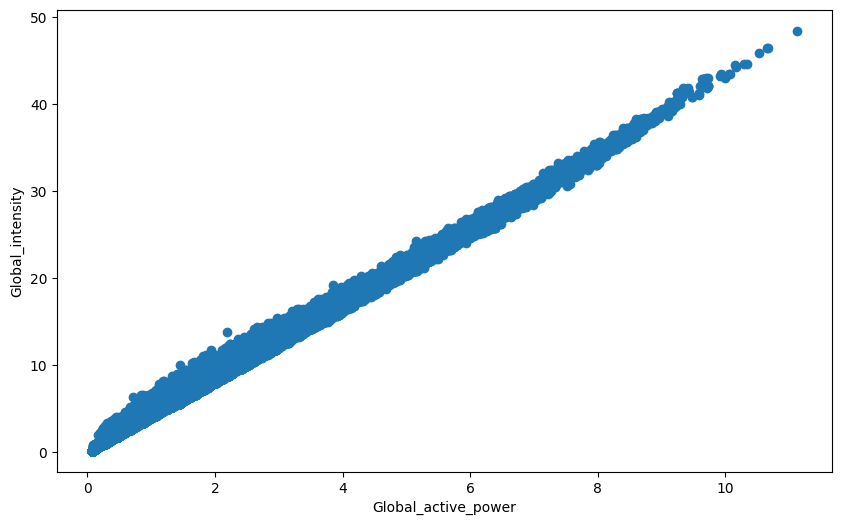

In [107]:
# TO DO
plt.figure(figsize=(10,6))
plt.scatter(df["Global_active_power"], df["Global_intensity"])
plt.xlabel("Global_active_power")
plt.ylabel("Global_intensity")
plt.show()

# 2. Prédiction standard
De façon classique, un modèle de prédiction indique une relation entre des variables d'entrée et une variable à prédire. Dans cette partie, nous allons prédire  **Global_active_power** en utilisant les autres colonnes.

#### Question 2.1   (5 points)
Pour l'ensemble des données, créer un ensemble de données nommé **data** en remplaçant la colonne **dt** par de nouvelles colonnes **annee**, **mois**, **jour**, **heure** et **minutes**. 
Indiquer pourquoi la colonne **secondes** peut être ignorée pour notre ensemble de données. 

In [108]:
# TO DO
data = df.copy()
data["annee"] = df["dt"].dt.year
data["mois"] = df["dt"].dt.month
data["jour"] = df["dt"].dt.day
data["heure"] = df["dt"].dt.hour
data["minutes"] = df["dt"].dt.minute
data = data.drop(columns=["dt"])
data.head()
# La colonne secondes peut être ignorée parce que la valeur ne change jamais pour chaque observation, elle est toujours de 0.

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,annee,mois,jour,heure,minutes
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006,12,16,17,24
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006,12,16,17,25
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006,12,16,17,26
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006,12,16,17,27
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006,12,16,17,28


#### Question 2.2 (5 points)
On peut normaliser les données. 

*   La `standardisation` normalise les données en soustrayant la moyenne et en divisant par l'écart-type
*   `Min-Max Scaling` normalise les données en les ramenant entre 0 et 1.

Réaliser la normalisation des données par `standardisation`. On peut utiliser la fonction `StandardScaler()` de `sklearn`.

In [109]:
# TO DO
from sklearn.preprocessing import StandardScaler

standardisation = StandardScaler()
numeric_columns = [ "Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]
data[numeric_columns] = standardisation.fit_transform(data[numeric_columns])
data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,annee,mois,jour,heure,minutes
0,2.955077,2.610721,-1.851816,3.098789,-0.182337,-0.051274,1.249421,2006,12,16,17,24
1,4.037085,2.770406,-2.225274,4.133800,-0.182337,-0.051274,1.130897,2006,12,16,17,25
2,4.050326,3.320432,-2.330213,4.133800,-0.182337,0.120487,1.249421,2006,12,16,17,26
3,4.063567,3.355917,-2.191324,4.133800,-0.182337,-0.051274,1.249421,2006,12,16,17,27
4,2.434881,3.586573,-1.592556,2.513782,-0.182337,-0.051274,1.249421,2006,12,16,17,28


#### Question 2.3 (5 points)
On va séparer les données en un ensemble d'entraînement et un ensemble de test qu'on va nommer respectivement 'data_train' et 'data_test'. Utiliser les données jusqu'à fin 2009 pour l'apprentissage, et celles de 2010 pour le test.

Effectuer la séparartion des données.

In [110]:
# TO DO
data_train = data[data["annee"] <= 2009].copy()
data_test = data[data["annee"] == 2010].copy()
data_train.head()
data_test.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,annee,mois,jour,heure,minutes
1600236,0.660540,0.996128,-0.058598,0.623761,-0.182337,-0.223036,1.367944,2010,1,1,0,0
1600237,0.651082,0.978386,-0.237612,0.623761,-0.182337,-0.223036,1.367944,2010,1,1,0,1
1600238,0.651082,0.978386,-0.212920,0.623761,-0.182337,-0.223036,1.486468,2010,1,1,0,2
1600239,0.618924,0.552559,-0.178969,0.578761,-0.182337,-0.223036,1.367944,2010,1,1,0,3
1600240,0.562176,-0.192638,-0.222179,0.533760,-0.182337,-0.223036,1.367944,2010,1,1,0,4


### Question 2.4 - Entrainement de modèle de régression linéaire

La régression linéaire consiste à trouver une fonction affine qui minimise la somme des carrés des erreurs. La fonction affine est définie par la formule suivante :
$$ f(x) = \beta_0 + \beta_1^T x $$
Il consiste à trouver les paramètres $\beta_0$ et $\beta_1$ qui minimisent $\sum_{i=1}^n (f(x_i) - y_i)^2=||y-X\beta||^2$ où $X$ est la matrice des données fournies au modèle et $y$ le vecteur des `Global_active_power`.

La métrique RMSE (Root Mean Square Error) est une métrique utilisée pour mesurer la différence moyenne entre les valeurs prédites par un modèle et les valeurs observées.

#### Question 2.4.1 (10 points )
Entrainer un modèle de regresion linéaire avec **data_train** et  calculer la RMSE correspondante aux données de l'ensemble de test.

In [111]:
# TO DO
data_train = data_train.dropna()

x_data_train = data_train.drop(columns=["Global_active_power"])
y_data_train = data_train["Global_active_power"]

regression = linear_model.LinearRegression()
regression.fit(x_data_train,y_data_train)

x_data_test = data_test.drop(columns=["Global_active_power"])
y_data_test = data_test["Global_active_power"]

y_data_pred = regression.predict(x_data_test)

rmse = np.sqrt(mean_squared_error(y_data_test, y_data_pred))
print(rmse)


0.03726071322435327


La prédiction est obtenue. On peut maintenant mesurer l'importance de chaque attribut dans la prédicition en se référant aux coefficients de la régression linéaire.
#### Question 2.4.2  (5 points)
Quels sont les trois attributs ayant le plus d'impact dans la prédiction ?

In [112]:
# TO DO
coef = regression.coef_
feat = x_data_train.columns

coef_df = pd.DataFrame({"feature": feat, "coef": coef})
coef_df["abs_coef"] = coef_df["coef"].abs()

most_impact = coef_df.sort_values(by="abs_coef", ascending=False).head(3)

print(most_impact)

# Les trois attributs avec le plus d'impact sont: Global_intensity, Global_reactive_power et Sub_metering_3

                 feature      coef  abs_coef
2       Global_intensity  0.999046  0.999046
0  Global_reactive_power -0.018671  0.018671
5         Sub_metering_3  0.017612  0.017612


In [113]:
# On copie les données pour les utiliser dans la partie 3. 
dft = df.copy()

# 3. Prédiction de série temporelle 
Dans la partie précédente, la prédiction d'une valeur nécessite la connaissance des valeurs des autres attributs de l'observation concernée. On n'a pas toujours ces valeurs et pourtant on peut faire de prédiction dans ces situations. Les séries temporelles sont plus adaptées dans ces situations. La prédiction de séries temporelles consiste à estimer les valeurs futures d’une variable en se basant sur ses observations passées. 

Dans la suite du TP, seuls les attributs **Global_active_power** et **dt** vont être utilisés. La cellule suivante permet de réduire les données.

In [114]:
# Exécuter ce code pour afficher les données obtenues.
# Si la colonne 'dt' n'apparait pas en 'indice', vous pouvez l'ajouter ici.
dft = dft.set_index("dt")
dft = dft['Global_active_power']
dft

dt
2006-12-16 17:24:00    4.216
2006-12-16 17:25:00    5.360
2006-12-16 17:26:00    5.374
2006-12-16 17:27:00    5.388
2006-12-16 17:28:00    3.666
                       ...  
2010-11-26 20:58:00    0.946
2010-11-26 20:59:00    0.944
2010-11-26 21:00:00    0.938
2010-11-26 21:01:00    0.934
2010-11-26 21:02:00    0.932
Name: Global_active_power, Length: 2049280, dtype: float64

## 3.1 Analyse préliminaire des données

#### Question 3.1.1 ( 3 points)
Calculer et afficher sur un graphe la consommation moyenne de **Global_active_power** pour chaque mois de l'année.

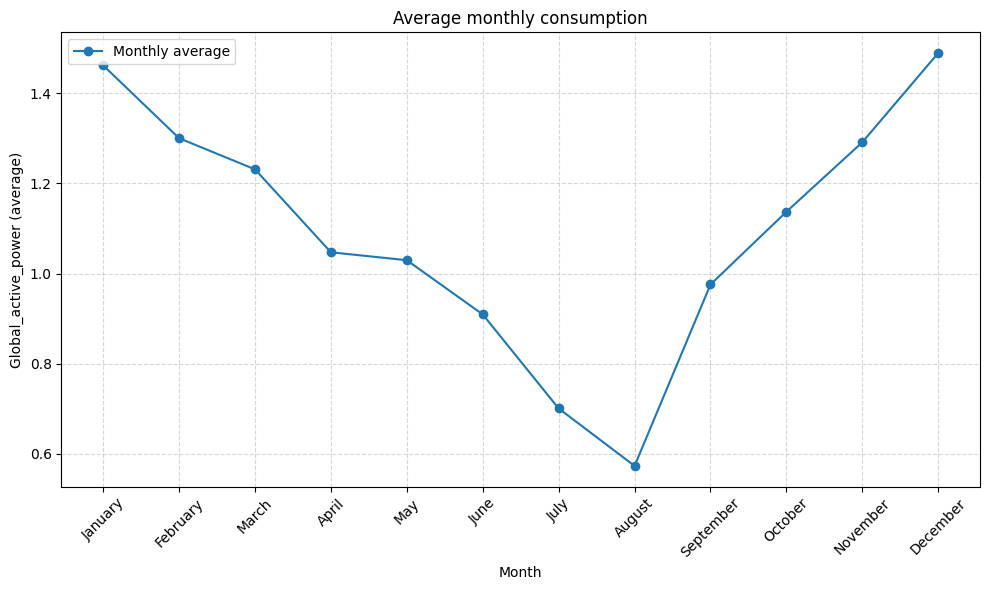

In [115]:
# TO DO
monthly_mean = dft.groupby(dft.index.month).mean()
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

plt.figure(figsize=(10, 6))
plt.plot(monthly_mean.index, monthly_mean.values, marker="o", label="Monthly average")
plt.xticks(range(1, 13), months, rotation=45)
plt.xlabel("Month")
plt.ylabel("Global_active_power (average)")
plt.title("Average monthly consumption")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Les données fournies sont en minutes. Pour la suite du TP, on va réduire la taille des données en faisant un rééchantillonnage des données en utilisant la somme par jour. La cellule suivante permet de faire cette réduction et de visualiser les données obtenues.

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_26964\2171113539.py:2: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  df_journalier = dft.resample('d').sum()


<Axes: xlabel='dt'>

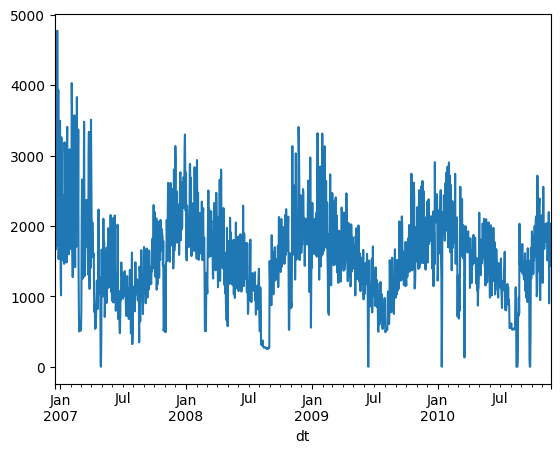

In [116]:
# Exécuter ce code pour afficher les données réduites
df_journalier = dft.resample('d').sum()
df_journalier.plot()

#### Question 3.1.2 (3 points)
En utilisant la fonction **seasonal_decompose** de la librairie **statsmodels**, effectuer une décomposition de la série temporelle journalière (df_journalier) avec une période de 6 mois.

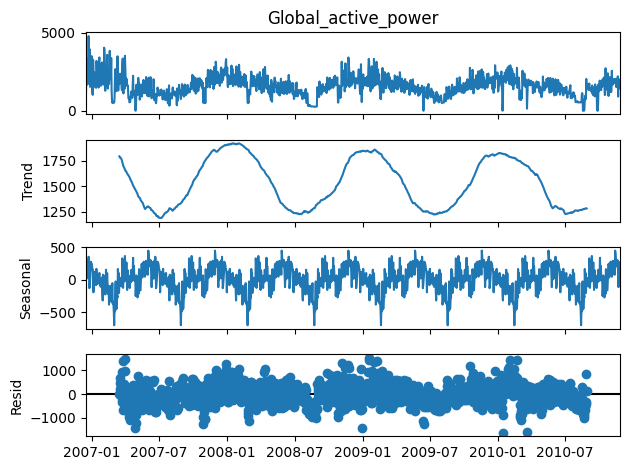

In [117]:
# TO DO
decomp = seasonal_decompose(df_journalier, model="additive", period=180)
decomp.plot()
plt.show()


#### Question 3.1.3 (4 points)
Interpréter les résultats obtenus aux questions 3.1.1 et 3.1.2. 
    Quelle périodicité observe-t-on ? 
    Quels mois présentent une consommation plus élevée ?
    Cette information est-elle cohérente avec un usage domestique ?

In [118]:
# TO DO
# On remarque grâce aux graphe seasonal que la périodicité est annuelle, Que les mois ayant une présence de consommation plus élevée sont les mois d'hiver (décembre, janvier, février). 
# Cette information est cohérente avec un usage domestique puisqu'en hiver, il y a beaucoup d'utilisation de chauffage électrique à cause des basses températures, il y a pas de pic anormales
# et il y a un rythme normale.
 

#### Question 3.1.4 (3 points)
Les **lag features** sont très utilisées dans la prédiction des séries temporelles. Elles permettent de saisir les tendances temporelles des données en générant de nouvelles variables à partir des valeurs passées. Ces variables permettent d'utiliser les valeurs passées pour prédire les valeurs futures. Par exemple, la prédiction de la consommation d'aujourd'hui pourrait dépendre de la consommation du même jour de l'année passée. Dans ce cas, la consommation d'il y a un an constituerait une lag feature.
Vous pouvez consulter le [lien](https://www.kaggle.com/code/ryanholbrook/time-series-as-features/tutorial) suivant pour un apperçu du lag embedding. 


Quelle valeur est adéqate pour une variable lagged dans ce cas ? Justifier votre réponse.

In [119]:
# TO DO (aucun code n'est requis pour répondre à cette question)
# La valeur adéquate pour une variable lagged dans notre cas serait 180 pour que se soit égale à la valeur de la période de 6 mois, donc 180 jours.

### 3.2  Modèle de régression linéaire 
Nous allons appliquer la régression linéaire sur nos données réduites. Pour cela, on doit transformer le problème de séries temporelles en un problème d'apprentissage supervisé. On va créer des "lagged features" pour accomplir cette tâche, puis diviser les données obtenues en des ensembles d'apprentissage et de test, respectivement les données jusqu'à fin 2009 pour l'apprentissage, et celles de 2010 pour le test. 

#### Question 3.2 (12.5 points)
Entraîner un modèle de regresion linéaire dans ce cas. Pour cela, créer une variable 'lags' permettant de garder en mémoire à chaque jour la consommation d'un jour du passé. Calculer la RMSE correspondante aux données prédites. 

In [120]:
# TO DO
df_lag = df_journalier.to_frame()
df_lag["lags"] = df_lag["Global_active_power"].shift(1)
df_lag = df_lag.dropna()

data_train = df_lag[df_lag.index.year < 2010]
x_data_train = data_train[["lags"]]
y_data_train = data_train["Global_active_power"]

data_test = df_lag[df_lag.index.year == 2010]
x_data_test = data_test[["lags"]]
y_data_test = data_test["Global_active_power"]

regression = linear_model.LinearRegression()
regression.fit(x_data_train, y_data_train)

y_pred = regression.predict(x_data_test)
rmse = np.sqrt(mean_squared_error(y_data_test, y_pred))
print(rmse)


415.5022095877549


### 3.3 Entrainement d'un modèle au choix
#### Question 3.3 (12.5 points)
Pour les mêmes périodes de sous-ensembles de données, entrainer un modèle de votre choix et calculer la RMSE correspondante. Justifiez votre choix.

Toute tranformation des données réduites avant l'entrainement est autorisée ici. L'obtention d'un RMSE meilleur au précédent sera valorisée. 

In [121]:
# TO DO
from sklearn.ensemble import RandomForestRegressor
# On a choisi le modele random forest car capture les cycles complexes. 
# L'ajout de nouvelles variables (jour, mois) lui donne le contexte nécessaire pour prédire plus efficacement les données que la régression linéaire et réduire le RMSE.

df_rf = df_journalier.to_frame()
df_rf["lags_day"] = df_rf["Global_active_power"].shift(1)
df_rf["lags_week"] = df_rf["Global_active_power"].shift(7)
df_rf["day_week"] = df_rf.index.dayofweek
df_rf["month"] = df_rf.index.month
df_rf = df_rf.dropna()

variables_x = ["lags_day", "lags_week", "day_week", "month"]

data_train_rf = df_rf[df_rf.index.year < 2010]
x_train_rf = data_train_rf[variables_x]
y_train_rf = data_train_rf["Global_active_power"]

data_test_rf = df_rf[df_rf.index.year == 2010]
x_test_rf = data_test_rf[variables_x]
y_test_rf = data_test_rf["Global_active_power"]

random_forest = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest.fit(x_train_rf, y_train_rf)

y_pred_rf = random_forest.predict(x_test_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
print(rmse_rf)

402.4642793444825


### 3.4 Évaluation des deux modèles 

#### Question 3.4.1 (7 points)
Pour chacun des deux modèles précédents, afficher sur une figure les observations réelles de **Global_active_power** et celles prédites en fonction du temps pour l'année 2010.

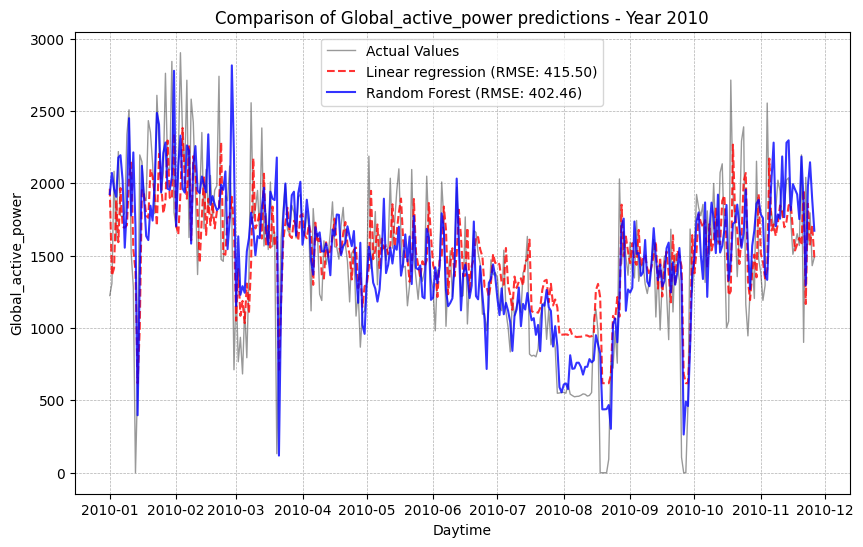

In [122]:
# TO DO
plt.figure(figsize=(10,6))
plt.plot(y_data_test.index, y_data_test.values, label="Actual Values", color='black', alpha=0.4, linewidth=1)
plt.plot(y_data_test.index, y_pred, label=f"Linear regression (RMSE: 415.50)", color='red', linestyle='--', alpha=0.8)
plt.plot(y_test_rf.index, y_pred_rf, label=f"Random Forest (RMSE: 402.46)", color='blue', alpha=0.8)

plt.title("Comparison of Global_active_power predictions - Year 2010")
plt.xlabel("Daytime")
plt.ylabel("Global_active_power")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

#### Question 3.4.2  (5 points)
En se basant sur les graphes obtenus à la question précédente et sur les RMSE obtenus pour les deux modèles, faites une analyse comparative des résultats. 

In [ ]:
# TO DO ( aucun code n'est requis pour répondre à  cette question)
# Le modèle Random Forest (RMSE 402) donne de meilleurs résultats que la régression linéaire (RMSE 415). 
# Sur le graphique, ses prédictions suivent mieux les vraies variations des données. Cette amélioration vient de l’ajout de variables liées au temps, 
# comme le jour et le mois, qui aident le modèle à mieux comprendre les variations saisonnières.